# Polarization CHSH analysis with propagated uncertainties

The detector-output Bell angles are **A1 = 0, A2 = pi, B1 = pi/2, B2 = 3pi/2**. The recorded phase origins are shifted, but this does not affect the analysis: correlations depend on the relative separation between settings, not on an absolute phase zero.

All quoted errors below are one-standard-deviation statistical uncertainties. They include repeat-to-repeat count uncertainty and the complete covariance matrix of every nonlinear fringe fit. A separate systematic uncertainty for phase calibration cannot be inferred because no phase-calibration errors were supplied.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import lib

# Resolve all data paths relative to this notebook rather than the shell's
# current directory. Jupyter normally starts in the notebook directory.
DATA_DIR = Path.cwd()

# Every measurement file has 33 rows and therefore uses phaseA. phaseB has
# 29 points and is a calibration for the other scanner; it is not silently
# mixed into these 33-point scans.
phase_a = np.loadtxt(DATA_DIR / 'phaseA.txt')
phase_b_calibration = np.loadtxt(DATA_DIR / 'phaseB.txt')
print(f'phaseA points: {len(phase_a)}; phaseB calibration points: {len(phase_b_calibration)}')

phaseA points: 33; phaseB calibration points: 29


In [2]:
# The first four curves are the four detector outcomes at Bob setting 0;
# the next four are the same outcomes at Bob setting pi/2. Each curve has
# three repeated files. load_coinc returns [mean, standard error] columns.
outcomes = ('A1B1', 'A1B2', 'A2B1', 'A2B2')
bob_suffixes = ('0', '90')
labels = [f'{outcome}_{suffix}' for suffix in bob_suffixes for outcome in outcomes]

coincidences = []
alice_singles = []
bob_singles = []

for suffix in bob_suffixes:
    for outcome in outcomes:
        repeated_files = [
            DATA_DIR / f'{outcome}_{suffix}_{repeat}.txt'
            for repeat in (1, 2, 3)
        ]
        coinc, singles_a, singles_b = lib.load_coinc(repeated_files, len(phase_a))
        coincidences.append(coinc)
        alice_singles.append(singles_a)
        bob_singles.append(singles_b)

# Report the largest singles and coincidence means with the error belonging
# to that same point. The original code accidentally took max over both the
# mean and error columns and duplicated A1B2 in its singles list.
for label, singles_a, singles_b, coinc in zip(
    labels, alice_singles, bob_singles, coincidences
):
    ia = np.argmax(singles_a[:, 0])
    ib = np.argmax(singles_b[:, 0])
    ic = np.argmax(coinc[:, 0])
    print(f'{label:8s}  max Alice singles = {singles_a[ia,0]:.0f} +/- {singles_a[ia,1]:.0f}')
    print(f'          max Bob singles   = {singles_b[ib,0]:.0f} +/- {singles_b[ib,1]:.0f}')
    print(f'          max coincidences  = {coinc[ic,0]:.4f} +/- {coinc[ic,1]:.4f}')

A1B1_0    max Alice singles = 1075631 +/- 2519
          max Bob singles   = 4045492 +/- 3033820
          max coincidences  = 38.2021 +/- 0.0577
A1B2_0    max Alice singles = 1038690 +/- 4061
          max Bob singles   = 1032151 +/- 446
          max coincidences  = 37.0237 +/- 0.3786
A2B1_0    max Alice singles = 1068521 +/- 985
          max Bob singles   = 1015964 +/- 2214
          max coincidences  = 37.4367 +/- 0.0333
A2B2_0    max Alice singles = 1077080 +/- 1285
          max Bob singles   = 1024538 +/- 2558
          max coincidences  = 36.9999 +/- 0.0265
A1B1_90   max Alice singles = 1082628 +/- 2975
          max Bob singles   = 1045258 +/- 369
          max coincidences  = 38.7021 +/- 0.3055
A1B2_90   max Alice singles = 1060940 +/- 1540
          max Bob singles   = 1016700 +/- 951
          max coincidences  = 36.8237 +/- 0.2517
A2B1_90   max Alice singles = 1077823 +/- 3969
          max Bob singles   = 1037524 +/- 5142
          max coincidences  = 37.9367 +/- 0.0333


In [3]:
# Initial values only guide the nonlinear minimizer; the fitted values and
# their covariance matrices are determined by the measurements.
initial_guesses = np.array([
    [20.0,  20.0, 1.0,  3.1],  # A1B1, Bob setting 0
    [20.0, -20.0, 1.0,  3.1],  # A1B2, Bob setting 0
    [20.0,  20.0, 1.0,  0.0],  # A2B1, Bob setting 0
    [20.0,  20.0, 1.0,  3.1],  # A2B2, Bob setting 0
    [20.0,  20.0, 1.0,  1.5],  # A1B1, Bob setting pi/2
    [20.0,  20.0, 1.0, -1.6],  # A1B2, Bob setting pi/2
    [20.0,  20.0, 1.0, -1.6],  # A2B1, Bob setting pi/2
    [20.0,  20.0, 1.0,  1.3],  # A2B2, Bob setting pi/2
])

fit_parameters = np.zeros((8, 4))
fit_covariances = np.zeros((8, 4, 4))
parameter_names = ('offset', 'amplitude', 'frequency', 'phase')

for index, (label, curve, guess) in enumerate(
    zip(labels, coincidences, initial_guesses)
):
    fit_parameters[index], fit_covariances[index] = lib.interf_curve(
        phase_a, curve, guess
    )
    parameter_errors = np.sqrt(np.diag(fit_covariances[index]))
    visibility, visibility_error = lib.visibility_with_error(
        fit_parameters[index], fit_covariances[index]
    )
    print(f'\n{label}')
    for name, value, error in zip(parameter_names, fit_parameters[index], parameter_errors):
        print(f'  {name:9s} = {value: .7f} +/- {error:.7f}')
    print(f'  visibility = {visibility:.7f} +/- {visibility_error:.7f}')


A1B1_0
  offset    =  18.9803357 +/- 0.0176533
  amplitude =  18.9689432 +/- 0.0196030
  frequency =  0.9999600 +/- 0.0007063
  phase     =  3.1258028 +/- 0.0015958
  visibility = 0.9993998 +/- 0.0013612

A1B2_0
  offset    =  18.8695426 +/- 0.0125906
  amplitude = -18.9921720 +/- 0.0116234
  frequency =  0.9925729 +/- 0.0004732
  phase     =  3.0998471 +/- 0.0010123
  visibility = 1.0064988 +/- 0.0004612

A2B1_0
  offset    =  18.8110528 +/- 0.0145126
  amplitude =  18.7858043 +/- 0.0146029
  frequency =  0.9935501 +/- 0.0006916
  phase     =  0.0085370 +/- 0.0017792
  visibility = 0.9986578 +/- 0.0005249

A2B2_0
  offset    =  18.6621102 +/- 0.0208199
  amplitude =  18.5417015 +/- 0.0199275
  frequency =  0.9938799 +/- 0.0006574
  phase     =  2.8912926 +/- 0.0008908
  visibility = 0.9935480 +/- 0.0020322

A1B1_90
  offset    =  19.3415457 +/- 0.0149494
  amplitude =  18.5155601 +/- 0.0201341
  frequency =  0.9946980 +/- 0.0004260
  phase     =  1.5177127 +/- 0.0011182
  visibility 

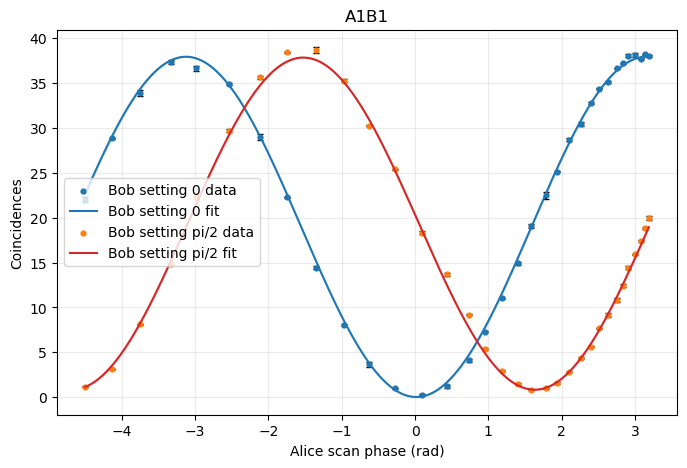

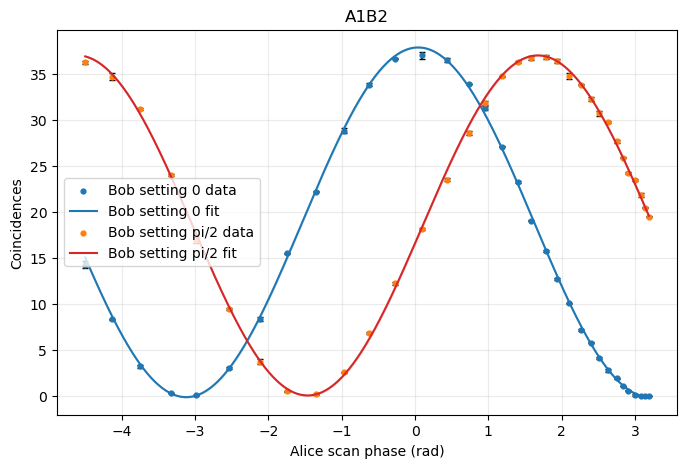

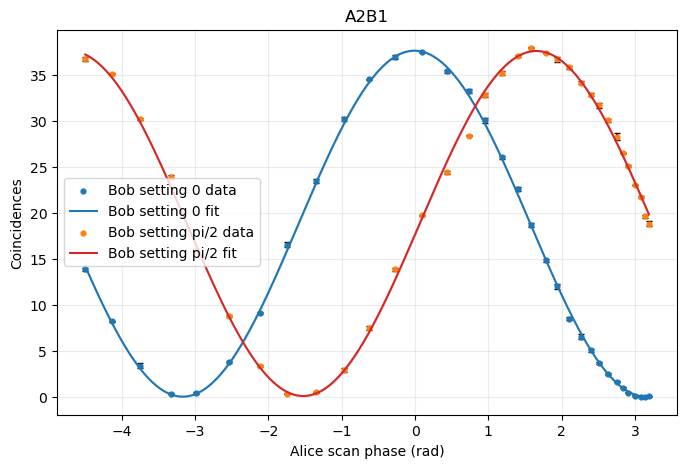

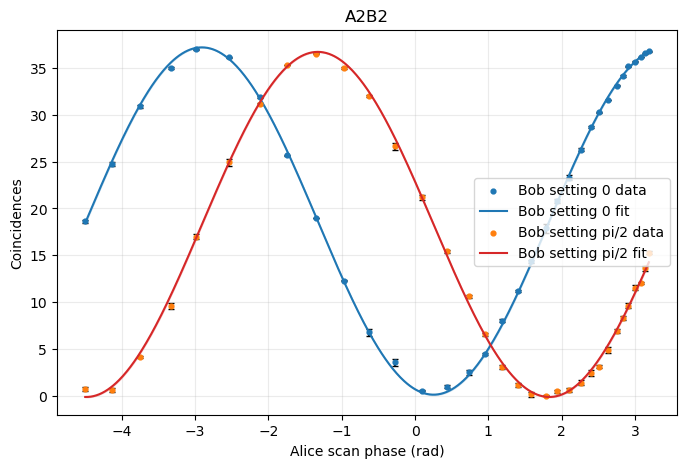

In [4]:
# Plot each pair of fringes. The translucent band is the propagated 1-sigma
# uncertainty of the fitted mean curve, not the scatter of new observations.
model_phase = np.linspace(phase_a.min(), phase_a.max(), 600)

for outcome_index, outcome in enumerate(outcomes):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
    for curve_index, color, setting_label in (
        (outcome_index, 'tab:blue', 'Bob setting 0'),
        (outcome_index + 4, 'tab:red', 'Bob setting pi/2'),
    ):
        lib.plot_coinc(phase_a, coincidences[curve_index], setting_label + ' data')
        model = lib.cos_f(model_phase, *fit_parameters[curve_index])
        model_error = np.array([
            lib.prediction_with_error(x, fit_parameters[curve_index],
                                      fit_covariances[curve_index])[1]
            for x in model_phase
        ])
        ax.plot(model_phase, model, color=color, label=setting_label + ' fit')
        ax.fill_between(model_phase, model - model_error, model + model_error,
                        color=color, alpha=0.18)
    ax.set(xlabel='Alice scan phase (rad)', ylabel='Coincidences', title=outcome)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

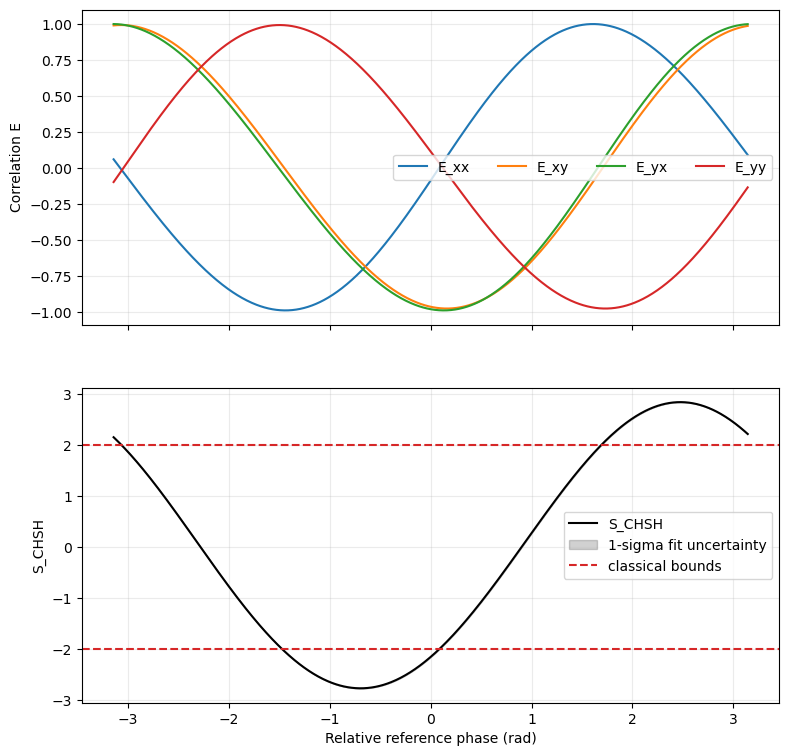

In [5]:
# Evaluate the four correlations and CHSH combination over one complete
# relative-phase period. chsh_with_error combines gradients before applying
# the covariance, which retains correlations between E values that reuse fits.
reference_phases = np.linspace(-np.pi, np.pi, 800)
s_values = np.empty_like(reference_phases)
s_errors = np.empty_like(reference_phases)
component_values = {name: np.empty_like(reference_phases)
                    for name in ('E_xx', 'E_xy', 'E_yx', 'E_yy')}

for index, reference_phase in enumerate(reference_phases):
    s_values[index], s_errors[index], components = lib.chsh_with_error(
        reference_phase, fit_parameters, fit_covariances
    )
    for name, (value, error) in components.items():
        component_values[name][index] = value

fig, (ax_e, ax_s) = plt.subplots(2, 1, figsize=(9, 9), dpi=100, sharex=True)
for name, values in component_values.items():
    ax_e.plot(reference_phases, values, label=name)
ax_e.set(ylabel='Correlation E')
ax_e.grid(alpha=0.25)
ax_e.legend(ncol=4)

ax_s.plot(reference_phases, s_values, color='black', label='S_CHSH')
ax_s.fill_between(reference_phases, s_values - s_errors, s_values + s_errors,
                  color='black', alpha=0.18, label='1-sigma fit uncertainty')
ax_s.axhline(2.0, color='tab:red', linestyle='--', label='classical bounds')
ax_s.axhline(-2.0, color='tab:red', linestyle='--')
ax_s.set(xlabel='Relative reference phase (rad)', ylabel='S_CHSH')
ax_s.grid(alpha=0.25)
ax_s.legend()
plt.show()

In [6]:
# Locate the continuous extrema rather than taking the largest grid point.
# The phase errors are propagated from the fit covariance using the local
# curvature condition dS/dphase = 0. Absolute phase zero remains arbitrary.
for kind in ('maximum', 'minimum'):
    phase, phase_error, s_value, s_error = lib.chsh_extremum_with_error(
        fit_parameters, fit_covariances, kind=kind
    )
    _, _, components = lib.chsh_with_error(phase, fit_parameters, fit_covariances)
    violation_sigma = (abs(s_value) - 2.0) / s_error

    print(f'\nCHSH {kind}')
    print(f'  relative phase = {phase:.7f} +/- {phase_error:.7f} rad')
    for name, (value, error) in components.items():
        print(f'  {name} = {value:+.7f} +/- {error:.7f}')
    print(f'  S = {s_value:+.7f} +/- {s_error:.7f}')
    print(f'  distance beyond |S|=2 = {violation_sigma:.1f} sigma (statistical only)')

print('\nImportant: add phase-calibration, angle-setting, detector-efficiency,')
print('and other systematic uncertainties separately if those calibrations become available.')


CHSH maximum
  relative phase = 2.4738664 +/- 0.0009342 rad
  E_xx = +0.6652421 +/- 0.0013324
  E_xy = +0.7034401 +/- 0.0010030
  E_yx = +0.7553036 +/- 0.0006779
  E_yy = -0.7163548 +/- 0.0010044
  S = +2.8403406 +/- 0.0015111
  distance beyond |S|=2 = 556.1 sigma (statistical only)

CHSH minimum
  relative phase = -0.6940994 +/- 0.0006315 rad
  E_xx = -0.7193916 +/- 0.0011364
  E_xy = -0.6526429 +/- 0.0010532
  E_yx = -0.6870238 +/- 0.0009079
  E_yy = +0.7022857 +/- 0.0008956
  S = -2.7613440 +/- 0.0021066
  distance beyond |S|=2 = 361.4 sigma (statistical only)

Important: add phase-calibration, angle-setting, detector-efficiency,
and other systematic uncertainties separately if those calibrations become available.
